In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr
import sys
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
with open("fit_palette.json") as f:
    pal = json.load(f)

In [4]:
sys.path.append("../../bosporus-package/")
from bosporus import *

sys.path.append("../src/")
from figure_2 import main

In [5]:
np.random.seed(41)

In [6]:
conconc = main()

calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...


In [7]:
conconc["entropy_AIC_weights"] /= np.log(3)

In [8]:
def get_sign(x, eps=0.0001):
    if np.abs(x) < eps:
        return "none"
    if x > 0:
        return "increase"
    else:
        return "decrease"
        
conconc["sign_border_effect"] = conconc["observed_effect_strength"].apply(lambda x: get_sign(x))

In [9]:
markers = {"decrease": "v", "increase": "^", "none": "o"}  # if fit monotonocially decreases, then error is positive at borders

In [10]:
index = {"delaunay": 0,
#         "knn_k=5": 1,
         "knn_k=10": 1,
#         "knn_k=15": 3,
#        "rnn_r=0.02": 4,
         "rnn_r=0.03": 2,
#         "rnn_r=0.04": 6,
#         "rnn_r=0.05": 7
         }

In [11]:
plot_subset = conconc[np.isin(conconc["graph_type"], list(index.keys()))]

In [12]:
for (gt, m), df in plot_subset.groupby(["graph_type", "measure"]):
    combis = [("observed_half_life", "observed_effect_strength"),
             ("observed_half_life", "num_edges"),
             ("observed_half_life", "num_nodes"),
             ("observed_effect_strength", "num_edges"),
             ("observed_effect_strength", "num_nodes")]
    for c in combis:
        stat = pearsonr(df[c[0]], df[c[1]]).statistic
        if stat > 0.3:
            print(gt, m, c[0], c[1], stat)

delaunay betweenness observed_effect_strength num_edges 0.4799395573411258
delaunay betweenness observed_effect_strength num_nodes 0.4799548548208277
delaunay closeness observed_effect_strength num_edges 0.7095737595314386
delaunay closeness observed_effect_strength num_nodes 0.7094483773488683
delaunay clustering observed_half_life observed_effect_strength 0.3717212852052387
delaunay harmonic observed_effect_strength num_edges 0.7511669087497272
delaunay harmonic observed_effect_strength num_nodes 0.7510285350214709
rnn_r=0.03 betweenness observed_half_life num_nodes 0.32896073042841256
rnn_r=0.03 closeness observed_half_life num_edges 0.35263936592477807
rnn_r=0.03 closeness observed_half_life num_nodes 0.4445372484278127
rnn_r=0.03 degree observed_half_life observed_effect_strength 0.4947732332894732
rnn_r=0.03 pagerank observed_half_life observed_effect_strength 0.4058944051283877


In [13]:
rel_ll_columns = ['Piecewise Linear Fit_scaled_relative_likelihood_over_Constant Fit', 'Exponential Saturation Fit_scaled_relative_likelihood_over_Constant Fit', 'Michaelis-Menten Fit_scaled_relative_likelihood_over_Constant Fit']

In [14]:
best_fit_rel_ll = plot_subset[rel_ll_columns].max(axis=1)

In [15]:
plot_subset["rel_ll_best"] = best_fit_rel_ll

/tmp/ipykernel_3133228/4020126070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_subset["rel_ll_best"] = best_fit_rel_ll


In [16]:
def clip_percentiles(group):
    x_low, x_high = group["observed_half_life"].quantile([0.01, 0.99])
    y_low, y_high = group["observed_effect_strength"].quantile([0.01, 0.99])

    return group[
        group["observed_half_life"].between(x_low, x_high) &
        group["observed_effect_strength"].between(y_low, y_high)
    ]

filtered = (
    plot_subset
    .reset_index()
    .groupby(["graph_type", "measure"], group_keys=False)
    .apply(clip_percentiles)
)

/tmp/ipykernel_3133228/1291924240.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(clip_percentiles)


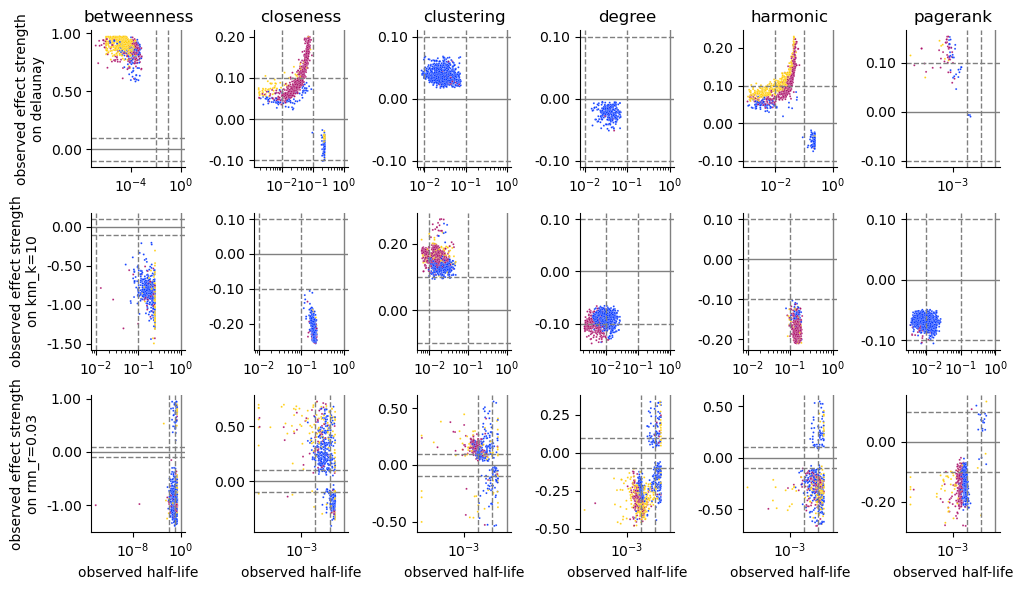

In [26]:
g = sns.relplot(data=filtered.reset_index(), x='observed_half_life', y='observed_effect_strength', hue="best_fit_type", row="graph_type", col="measure", palette=pal, hue_order=pal.keys(), kind='scatter', facet_kws={"sharex": False, "sharey": False}, alpha=0.9, height=2, aspect=6/7, row_order=index.keys(), col_order=sorted(conconc["measure"].unique()), s=2, legend=False)
for i, ax in enumerate(g.axes.flat):
    ax.axhline(0, linestyle='-', linewidth=1, color="grey")
    ax.axhline(-0.1, linestyle='--', linewidth=1, color="grey")
    ax.axhline(0.1, linestyle='--', linewidth=1, color="grey")

    ax.axvline(0.01, linestyle='--', linewidth=1, color="grey")
    ax.axvline(0.1, linestyle='--', linewidth=1, color="grey")
    ax.axvline(1, linestyle='-', linewidth=1, color="grey")

    #ax.set_ylim(-2, 2)
    
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.set_xscale("log")   
    #ax.set_yscale("symlog")   

    original_title = ax.get_title()

    if i >= 6:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])

    if i % 6 == 0:
        t = original_title.split("graph_type = ")[1].split(" |")[0]
        ax.set_ylabel(f"observed effect strength\non {t}")

    if i >= 12 :
        ax.set_xlabel(f"observed half-life")

plt.tight_layout()
plt.savefig("../result_plots/fits/observed_effect_strength_over_observed_half_life.pdf", bbox_inches="tight")

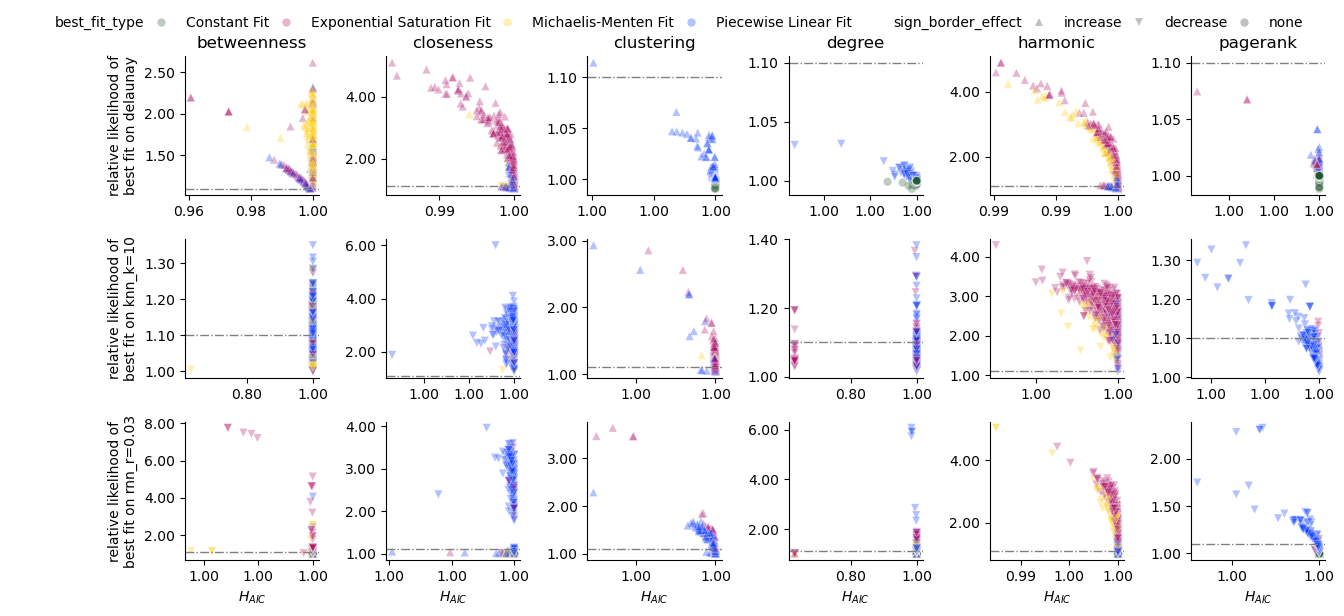

In [18]:
g = sns.relplot(data=filtered, x="entropy_AIC_weights", y="rel_ll_best", hue="best_fit_type", style="sign_border_effect", row="graph_type", col="measure", palette=pal, hue_order=pal.keys(), markers=markers, legend='auto', kind='scatter', facet_kws={"sharex": False, "sharey": False}, alpha=0.3, height=2, aspect=6/7, col_order=sorted(conconc["measure"].unique()), row_order=index.keys())
for i, ax in enumerate(g.axes.flat):
    ax.axhline(1.1, linestyle='-.', linewidth=1, color="grey")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    original_title = ax.get_title()

    if i >= 6:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])
    if i % 6 == 0:
        t = original_title.split("graph_type = ")[1].split(" |")[0]
        ax.set_ylabel(f"relative likelihood of\nbest fit on {t}")
    if i >= 12 :
        ax.set_xlabel("$H_{AIC}$")

sns.move_legend(g,
    loc='upper center',
    bbox_to_anchor=(0.45, 1.03),
    ncol=9,
    frameon=False,
    columnspacing =0.2
)
plt.tight_layout()
plt.savefig("../result_plots/fits/relative_likelihoods_over_model_agreement.pdf", bbox_inches="tight")

In [19]:
for graph_type, df in conconc.sort_values(['graph_type'], ascending=False).groupby("graph_type"):
    print(graph_type)

delaunay
knn_k=10
knn_k=15
knn_k=5
rnn_r=0.02
rnn_r=0.03
rnn_r=0.04
rnn_r=0.05


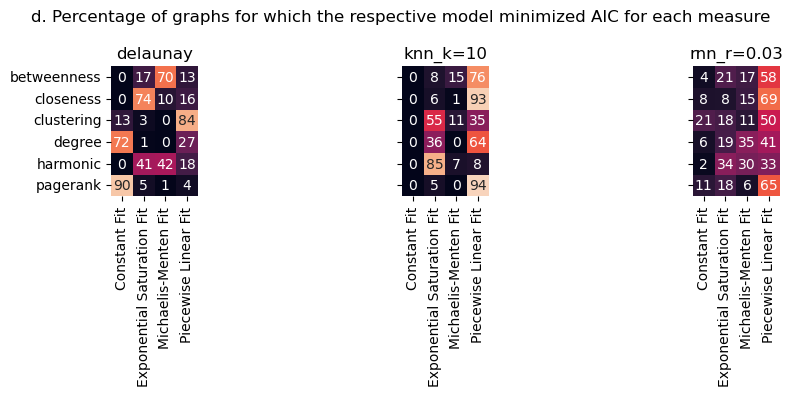

In [20]:
f, axs = plt.subplots(1, len(index), figsize=(10, 4), sharey=True)
for graph_type, df in plot_subset.sort_values(['graph_type'], ascending=False).groupby("graph_type"):
    i = index[graph_type]
    heatmap = pd.crosstab(df["measure"].values, df["best_fit_type"].values, normalize="index")*100
    sns.heatmap(heatmap, annot=True, square=True, fmt=".0f", ax=axs[i], cbar=False, vmin=0, vmax=100)
    axs[i].set_ylabel(None)
    axs[i].set_xlabel(None)
    axs[i].set_title(graph_type)
plt.suptitle("d. Percentage of graphs for which the respective model minimized AIC for each measure")
plt.tight_layout()
#plt.savefig("../result_plots/fits/AICS_type.svg", bbox_inches="tight")

In [21]:
filtered

,index,Unnamed: 0.1,Unnamed: 0,measure,best_fit_type,entropy_AIC_weights,observed_half_life,observed_effect_strength,included samples,affected samples,...,michaelis_menten_c,piecewise_linear_b,piecewise_linear_m,piecewise_linear_c,dataset,num_edges,num_nodes,graph_type,sign_border_effect,rel_ll_best
2,2,2,2,betweenness,Michaelis-Menten Fit,1.000000,0.000033,0.865872,1.0,0.021626,...,0.104147,NaN,NaN,NaN,glioma_mibitof:Brainiaqc_R6C3_whole_cell.tiff,3446,1156,delaunay,increase,1.374859
8,8,8,2,betweenness,Michaelis-Menten Fit,1.000000,0.000043,0.890076,1.0,0.019350,...,0.118548,NaN,NaN,NaN,glioma_mibitof:Brainiaqc_R4C4_whole_cell.tiff,3853,1292,delaunay,increase,1.547249
14,14,14,2,betweenness,Piecewise Linear Fit,1.000000,0.000198,0.857055,1.0,0.022222,...,NaN,0.000396,-261.168716,0.111959,glioma_mibitof:CHOP_907_R11C10_whole_cell.tiff,2546,855,delaunay,increase,1.495797
20,20,20,2,betweenness,Michaelis-Menten Fit,0.999614,0.000013,0.912492,1.0,0.013380,...,0.121244,NaN,NaN,NaN,glioma_mibitof:CHOP_1101_R6C3_whole_cell.tiff,5136,1719,delaunay,increase,1.571230
26,26,26,2,betweenness,Michaelis-Menten Fit,0.999998,0.000017,0.921486,1.0,0.017785,...,0.132052,NaN,NaN,NaN,glioma_mibitof:Brainiaqc_R3C5_whole_cell.tiff,5205,1743,delaunay,increase,1.777394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18713,6221,6221,5,pagerank,Piecewise Linear Fit,0.999619,0.007792,-0.172627,1.0,0.072472,...,NaN,0.015584,0.001494,0.000056,glioma_mibitof:UCSF_TA6_R99C2_whole_cell.tiff,220417,12805,rnn_r=0.03,decrease,1.269877
18719,6227,6227,5,pagerank,Piecewise Linear Fit,0.999734,0.007882,-0.172787,1.0,0.069756,...,NaN,0.015763,0.001560,0.000059,TNBC_mibitof:p30_labeledcellData.tiff,201104,12128,rnn_r=0.03,decrease,1.214085
18725,6233,6233,5,pagerank,Piecewise Linear Fit,0.999715,0.007890,-0.173269,1.0,0.066861,...,NaN,0.015780,0.001284,0.000048,glioma_mibitof:Brainiaqc_R3C3_whole_cell.tiff,297376,14747,rnn_r=0.03,decrease,1.244371
18731,6239,6239,5,pagerank,Piecewise Linear Fit,0.999626,0.007899,-0.169291,1.0,0.073454,...,NaN,0.015798,0.001446,0.000056,glioma_mibitof:UCSF_TA8_R99C2_whole_cell.tiff,221693,12838,rnn_r=0.03,decrease,1.262506


/tmp/ipykernel_3133228/2477202014.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.displot(data=filtered, fill=True, x="affected samples", y="observed_effect_strength", row="graph_type", col="measure", palette=pal, bins=(10,10), legend='auto', kind='kde', facet_kws={"sharex": False, "sharey": False}, alpha=0.3, height=2, aspect=6/7, col_order=sorted(conconc["measure"].unique()), row_order=index.keys())
/data/bionets/je30bery/conda/envs/bosporus/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'bins'
  cset = contour_func(


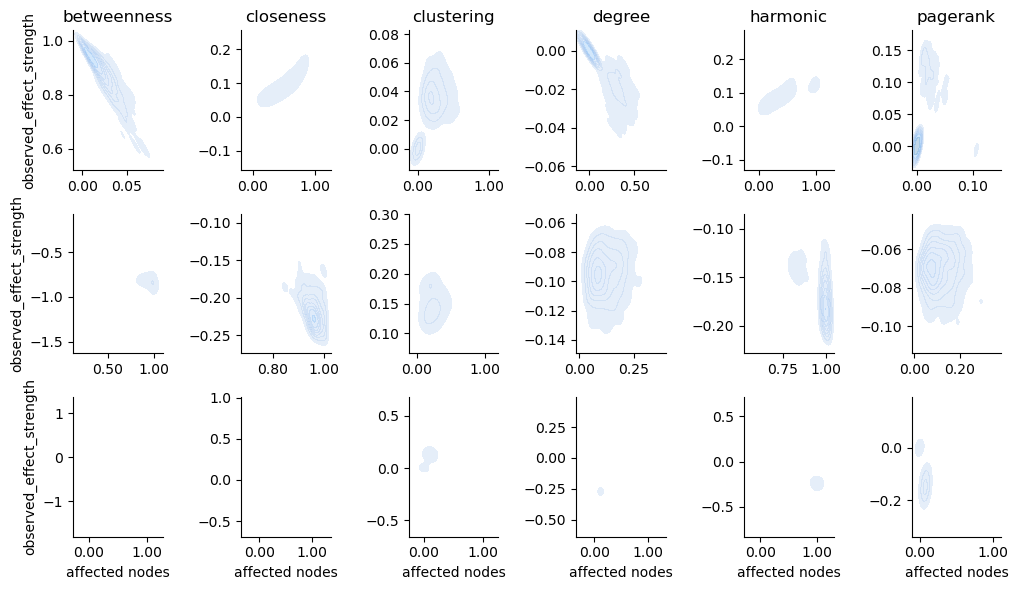

In [22]:
g = sns.displot(data=filtered, fill=True, x="affected samples", y="observed_effect_strength", row="graph_type", col="measure", palette=pal, bins=(10,10), legend='auto', kind='kde', facet_kws={"sharex": False, "sharey": False}, alpha=0.3, height=2, aspect=6/7, col_order=sorted(conconc["measure"].unique()), row_order=index.keys())
for i, ax in enumerate(g.axes.flat):
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    original_title = ax.get_title()

    if i >= 6:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])
    #if i % 6 == 0:
    #    t = original_title.split("graph_type = ")[1].split(" |")[0]
    #    ax.set_ylabel(f"relative likelihood of\nbest fit on {t}")
    if i >= 12 :
        ax.set_xlabel("affected nodes")


plt.tight_layout()
plt.savefig("../result_plots/fits/affected_nodes.pdf", bbox_inches="tight")

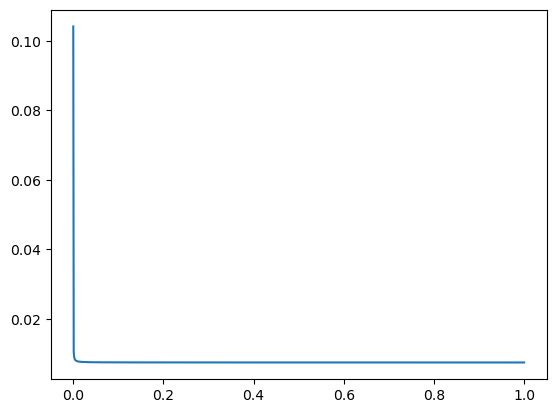

In [23]:
d = np.linspace(0, 1, 1000)
C = MichaelisMentenFit.michaelis_menten(d=d, a=filtered.loc[2, "michaelis_menten_a"], b=filtered.loc[2, "michaelis_menten_b"], c=filtered.loc[2, "michaelis_menten_c"])
plt.plot(d, C)

In [24]:
filtered.loc[6115]

index                                                                                                       6115
Unnamed: 0.1                                                                                                6115
Unnamed: 0                                                                                                     1
measure                                                                                                closeness
best_fit_type                                                                         Exponential Saturation Fit
entropy_AIC_weights                                                                                     0.998929
observed_half_life                                                                                      0.063801
observed_effect_strength                                                                                0.175638
included samples                                                                                

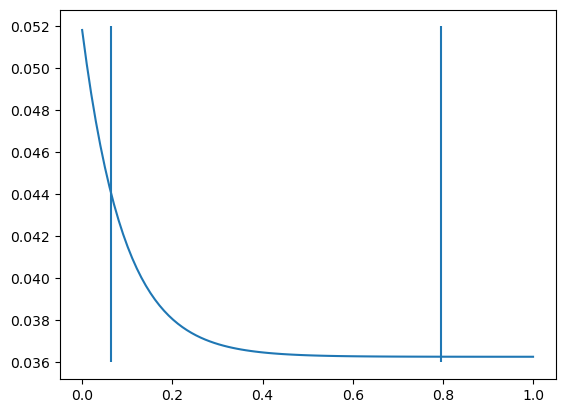

In [25]:
d = np.linspace(0, 1, 100)
C = ExponentialSaturationFit.exp_sat(d=d, a=-0.01556, b= 10.7906, c=0.051832)
plt.plot(d, C)
plt.vlines(0.063801, ymin=0.036, ymax=0.052)
plt.vlines(0.795768, ymin=0.036, ymax=0.052)
plt.savefig("../result_plots/fits/explanatory_fit.svg")